In [1]:
from IPython.display import Markdown, display, Math
import sympy as sp

from src.charts import fork
from src.charts import trail

Hello


# Motorcycle Stability Analysis. Tank Slapper Phenomena


## 1. Introduction

<div>
<img src="assets/10938-675-SR-R-2025-1000px.webp" width="300" style="float: left; margin-right: 15px;">
<p style="margin-left: 20px">Motorcycles are among the most dynamically complex vehicles on the road. Unlike a car, which distributes its stability across four contact patches, a motorcycle balances on just two - relying entirely on the physics of its geometry, gyroscopic forces, and rider input.

This delicate balance is what makes them thrilling to ride, but it also makes them vulnerable to a terrifying phenomenon known as a **Tank Slapper** - a violent, high-frequency oscillation of the handlebars that can occur at speed with little to no warning.

To grasp a better understading of the phenomena, we will, firstly, investigate the mathematical foundations behind motorcycle front-end stability. Starting from basic steering geometry (rake and trail), we build up through gyroscopic effects and the caster self-centering mechanism to arrive at a simplified model of the **wobble mode** - the oscillatory instability responsible for the tank slapper event.

Our goal is to answer three questions:

1. **What geometric and physical parameters govern front-end stability?**
2. **At what circumstances does the steering system become unstable?**
3. **How can this instability be prevented or mitigated?**

We approach these questions using symbolic mathematics and numerical visualization, demonstrating that the onset of a tank slapper is not random - it is a predictable consequence of the system's eigenvalues crossing into the unstable region of the complex plane.</p>
</div>

## 2. Rake & Trail

If we try to group motorcycles info a few

The most fundamental parameters governing a motorcycle's straight-line stability are **rake** and **trail** — two geometric quantities defined entirely by the front-end layout.

### Definitions

| Parameter | Description |
|---|---|
| **Rake angle** ($\lambda$) | The angle between the steering axis and the vertical. Typical values range from ~23° (sport bikes) to ~33° (cruisers). |
| **Fork offset** ($d$) | The perpendicular distance from the steering axis to the front axle (also called *triple-clamp offset*). |
| **Wheel radius** ($R$) | The radius of the front wheel including the tyre. |
| **Mechanical trail** ($t$) | The horizontal distance on the ground between the steering axis intersection and the tyre contact patch. |

The contact patch *trails behind* the steering axis — hence the name. This geometry is the reason the front wheel naturally self-centres: any lateral force at the contact patch creates a restoring moment about the steering axis proportional to the trail distance.

### Why trail matters

- **Too little trail** → weak self-centering, nervous handling, susceptibility to wobble.
- **Too much trail** → heavy, sluggish steering; the bike resists turn-in.
- The "sweet spot" depends on intended use — sport machines aim for 80–100 mm, while touring/cruiser setups push 100–130 mm.

### Symbolic derivation of the trail formula

Looking at the geometry from the side, the steering axis hits the ground at a distance $R \sin\lambda$ ahead of the axle's vertical projection. Subtracting the fork offset (projected onto the ground plane) and dividing by $\cos\lambda$ to convert along-axis distance to horizontal distance gives the **mechanical trail**:

In [2]:
lam, d, R, t = sp.symbols(r'\lambda d R t', positive=True)

trail_expr = (R * sp.sin(lam) - d) / sp.cos(lam)

display(Math(r't = \frac{R\,\sin\lambda - d}{\cos\lambda}'))

display(Markdown("**Simplified (expanded) form:**"))
trail_expanded = sp.simplify(trail_expr)
display(Math(f't = {sp.latex(trail_expanded)}'))

display(Markdown("**Numerical example** — sport-bike with $\\lambda = 25°$, $d = 30\\,\\text{mm}$, $R = 315\\,\\text{mm}$:"))

trail_numeric = trail_expr.subs({lam: sp.rad(25), d: 30, R: 315})
trail_val = float(trail_numeric.evalf())
display(Math(rf't = {trail_val:.1f}\;\text{{mm}}'))

<IPython.core.display.Math object>

**Simplified (expanded) form:**

<IPython.core.display.Math object>

**Numerical example** — sport-bike with $\lambda = 25°$, $d = 30\,\text{mm}$, $R = 315\,\text{mm}$:

<IPython.core.display.Math object>

### Visualising the front-end geometry

The diagram below renders the wheel, fork tubes, and steering axis for a given set of parameters. The **green arrow** on the ground marks the mechanical trail — the lever arm that creates the self-centering moment.

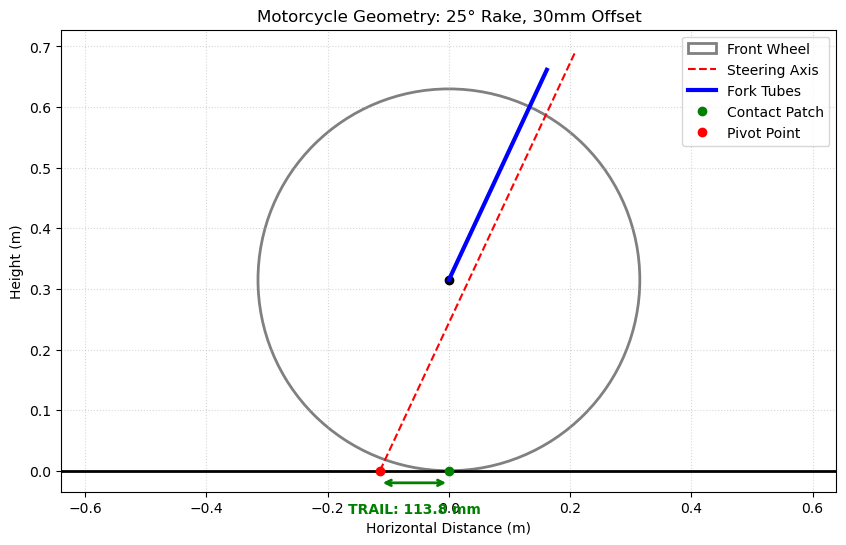

In [3]:
fork.plot_fork_geometry(rake_deg=25, offset_mm=30, wheel_radius_mm=315)

### Parametric sweep: trail vs. rake angle

How does trail change as we vary the rake angle? The plot below sweeps $\lambda$ from 20° to 35° for three common fork offsets. Two shaded bands highlight the typical sport-bike and cruiser operating windows.

Notice:
- Trail grows roughly linearly with rake in this range.
- A **smaller offset** increases trail at every rake angle — the fork pushes the axle closer to the steering axis.
- Sport bikes live in the lower-left corner (short trail, low rake), while cruisers sit in the upper-right (long trail, high rake).

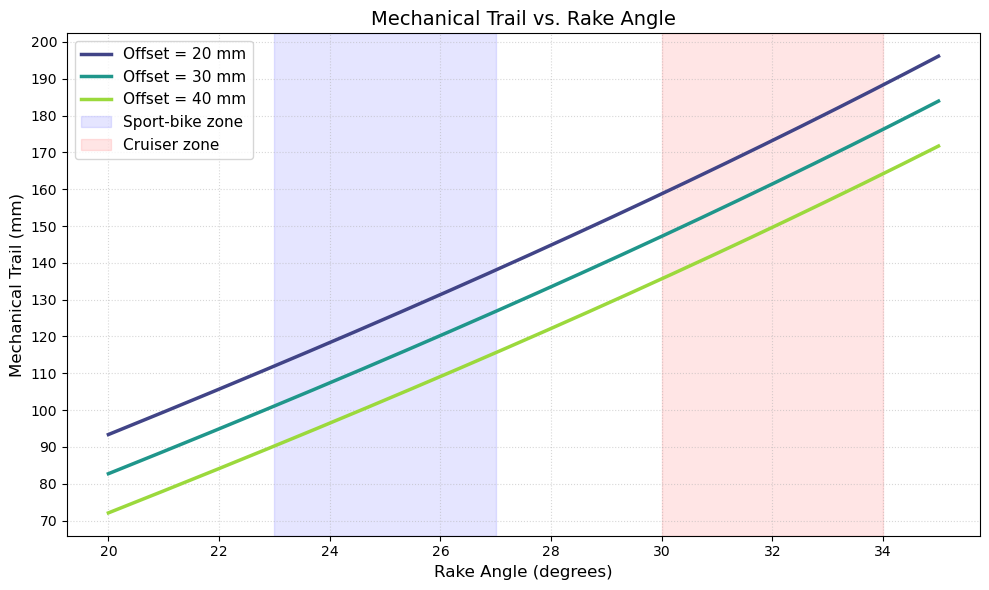

In [4]:
trail.plot_trail_vs_rake(
    rake_range=(20, 35),
    offsets_mm=(20, 30, 40),
    wheel_radius_mm=315,
)